In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
X_train = pd.read_csv('X_train_ohe_int.csv')
X_test = pd.read_csv('X_test_ohe_int.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

In [3]:
log_reg = LogisticRegression(max_iter=1000, solver='liblinear') 
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [4]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]  

In [5]:
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

In [6]:
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Recall: 0.5000
ROC-AUC: 0.8286

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



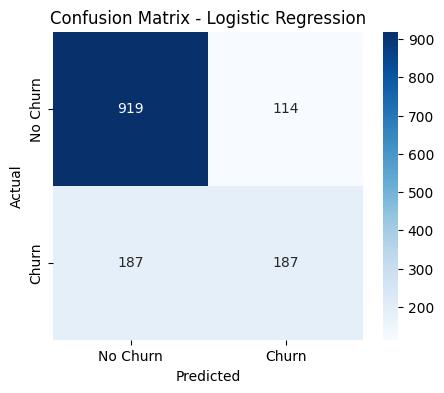

In [7]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [8]:
# GridSearch untuk Logistic Regression (fokus menaikkan Recall, sambil pantau ROC-AUC)
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, roc_auc_score

# ===== 1) Load data =====
X_train = pd.read_csv('X_train_ohe_int.csv')
X_test = pd.read_csv('X_test_ohe_int.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

# ===== 2) Siapkan model & parameter grid =====
# Dua grid supaya kompatibel dengan masing-masing solver
param_grid = [
    {
        "solver": ["liblinear"],            # cepat & support L1/L2
        "penalty": ["l1", "l2"],
        "C": np.logspace(-3, 2, 10),        # 0.001 s/d 100
        "class_weight": [None, "balanced"],
        "max_iter": [2000],
        "random_state": [42]
    },
    {
        "solver": ["lbfgs"],                # stabil utk L2, tanpa L1
        "penalty": ["l2"],
        "C": np.logspace(-3, 2, 10),
        "class_weight": [None, "balanced"],
        "max_iter": [2000],
        "random_state": [42]
    },
]

logreg = LogisticRegression()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Multi-metric: kita refit berdasarkan recall, tapi simpan ROC-AUC juga
grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring={"recall": "recall", "roc_auc": "roc_auc"},
    refit="recall",                 # pilih model dengan recall CV terbaik
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# ===== 3) Jalankan GridSearch =====
grid.fit(X_train, y_train)

print("\nBest params (by Recall):", grid.best_params_)
print("CV Recall (mean±std): %.4f ± %.4f" % (
    grid.cv_results_["mean_test_recall"][grid.best_index_],
    grid.cv_results_["std_test_recall"][grid.best_index_]
))
print("CV ROC-AUC (mean):    %.4f" % grid.cv_results_["mean_test_roc_auc"][grid.best_index_])

# ===== 4) Evaluasi di test set =====
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_recall = recall_score(y_test, y_pred)
test_rocauc = roc_auc_score(y_test, y_proba)

print("\n=== Test Performance (Best LR) ===")
print(f"Recall  : {test_recall:.4f}")
print(f"ROC-AUC : {test_rocauc:.4f}")

# (Opsional) Lihat 5 kombinasi terbaik berdasarkan recall CV
cv_df = pd.DataFrame(grid.cv_results_)
top5 = (
    cv_df.sort_values("mean_test_recall", ascending=False)
         .loc[:, ["mean_test_recall", "mean_test_roc_auc", "param_solver", "param_penalty", "param_C", "param_class_weight"]]
         .head(5)
)
print("\nTop-5 CV Results (by Recall):")
print(top5.to_string(index=False))


Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best params (by Recall): {'C': np.float64(0.001), 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear'}
CV Recall (mean±std): 0.9104 ± 0.0190
CV ROC-AUC (mean):    0.7516

=== Test Performance (Best LR) ===
Recall  : 0.8021
ROC-AUC : 0.7608

Top-5 CV Results (by Recall):
 mean_test_recall  mean_test_roc_auc param_solver param_penalty  param_C param_class_weight
         0.910368           0.751623    liblinear            l1 0.001000           balanced
         0.807358           0.835718    liblinear            l2 0.001000           balanced
         0.806020           0.829961        lbfgs            l2 0.001000           balanced
         0.795318           0.843429    liblinear            l2 0.599484           balanced
         0.794649           0.843412        lbfgs            l2 0.599484           balanced
